# MScFE 642 — Deep Learning for Finance
## Group Work Project 1 — Multi-asset return prediction and tactical allocation

| Asset class | ETF |
|---|---|
| Equity | SPY — SPDR S&P 500 |
| Fixed income (long duration) | TLT — iShares 20+ Year Treasury Bond |
| Cash-like (short duration) | SHY — iShares 1-3 Year Treasury Bond |
| Precious metals | GLD — SPDR Gold Shares |
| Crude oil | DBO — Invesco DB Oil Fund |

Step 1 exploratory analysis

Step 2 MLP

Step 3 CNN on Gramian AngularFields

Step 4 LSTM

Step 5 multi-output LSTM

Step 6 tactical allocation backtest

In [ ]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.titlesize": 10, "axes.labelsize": 9,
                     "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8})

# ----- configuration -------------------------------------------------------
TICKERS   = ["SPY", "TLT", "SHY", "GLD", "DBO"]
LABELS    = {"SPY": "Equity", "TLT": "Fixed income (long)", "SHY": "Cash-like",
             "GLD": "Precious metals", "DBO": "Crude oil"}
START       = "2007-01-05"       # DBO's inception limits the common history
END         = "2022-12-31"       # yfinance end date is exclusive
TEST_SAMPLE = ("2018-01-01", "2022-12-30")
LOOKBACK    = 30                 # trading days of history fed to every model
HORIZON     = 25                 # forecast horizon, trading days
SEEDS       = [0, 1, 2]          # each model is an average over three seeds
COST_BPS    = 5.0                # per unit of turnover at each rebalance
SPLITS      = [("train", "2007-01-05", "2014-12-31"),
               ("val",   "2015-01-01", "2017-12-29"),
               ("test",  "2018-01-01", "2022-12-30")]
ANN = 252                        # trading days per year

print("configuration loaded")

configuration loaded


## Step 1 — Data and exploratory analysis

Daily prices are downloaded with `yfinance` using adjusted closes, so dividends and splits
are reinvested.

In [ ]:
def load_local(folder="data"):
    """Read the cached yfinance CSV files when network access is unavailable."""
    import os
    out = {}
    for t in TICKERS:
        df = pd.read_csv(os.path.join(folder, f"{t}.csv"), skiprows=[1, 2])
        df = df.rename(columns={df.columns[0]: "Date"})
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.dropna(subset=["Date"]).set_index("Date")
        out[t] = pd.to_numeric(df["Close"], errors="coerce").dropna()
    return pd.DataFrame(out)

try:
    import yfinance as yf
    px = pd.DataFrame({
        t: yf.download(t, start=START, end=END, auto_adjust=True,
                       progress=False)["Close"].squeeze()
        for t in TICKERS})
    print("Prices downloaded with yfinance.")
except Exception as exc:
    print(f"yfinance unavailable ({type(exc).__name__}); using cached CSV files.")
    px = load_local()

px = px.dropna().sort_index().loc[:TEST_SAMPLE[1]]
rets = np.log(px).diff().dropna()
test_px = px.loc[TEST_SAMPLE[0]:TEST_SAMPLE[1]]

quality = pd.DataFrame({
    "asset class": pd.Series(LABELS),
    "first observation": px.apply(lambda s: s.first_valid_index().date()),
    "last observation": px.apply(lambda s: s.last_valid_index().date()),
    "observations": px.count(),
    "missing": px.isna().sum(),
    "non-positive prices": (px <= 0).sum(),
})
print(f"Common history: {px.index[0].date()} to {px.index[-1].date()} "
      f"({len(px):,} trading days, {len(rets):,} daily returns)")
print(f"Required test window: {test_px.index[0].date()} to {test_px.index[-1].date()} "
      f"({len(test_px):,} trading days)")
display(quality)

Prices downloaded with yfinance.
Common history: 2007-01-05 to 2022-12-30 (4,026 trading days, 4,025 daily returns)
Required test window: 2018-01-02 to 2022-12-30 (1,259 trading days)


,asset class,first observation,last observation,observations,missing,non-positive prices
SPY,Equity,2007-01-05,2022-12-30,4026,0,0
TLT,Fixed income (long),2007-01-05,2022-12-30,4026,0,0
SHY,Cash-like,2007-01-05,2022-12-30,4026,0,0
GLD,Precious metals,2007-01-05,2022-12-30,4026,0,0
DBO,Crude oil,2007-01-05,2022-12-30,4026,0,0


### Individual Distribution

Full common history, 2007-2022
Annualised mean and volatility by sample period


,asset class,annualised mean %,annualised volatility %,daily min %,daily max %,skewness,excess kurtosis,total return %
SPY,Equity,8.23,20.51,-11.59,13.56,-0.36,13.12,272.04
TLT,Fixed income (long),3.62,15.21,-6.90,7.25,0.02,3.64,78.36
SHY,Cash-like,1.43,1.40,-0.66,0.71,-0.00,7.68,25.76
GLD,Precious metals,6.49,17.72,-9.19,10.70,-0.25,6.58,181.93
DBO,Crude oil,-2.41,32.08,-18.21,10.10,-0.57,4.65,-31.92


train           val          test       
    mean %  vol % mean %  vol % mean %  vol %
SPY   6.85  22.18  10.75  12.32   8.91  21.64
TLT   7.97  15.38   2.72  12.98  -2.78  16.13
SHY   2.30   1.54   0.50   0.94   0.62   1.40
GLD   7.96  20.72   2.84  13.63   6.33  14.38
DBO  -4.91  29.98 -14.56  33.00   8.88  34.68

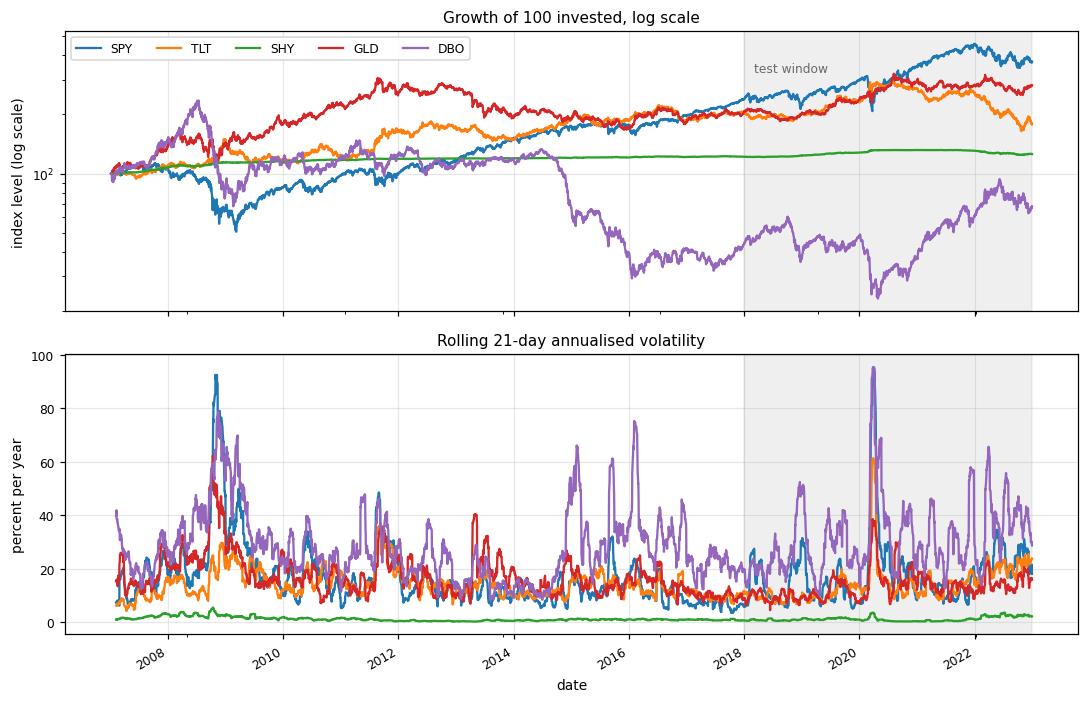

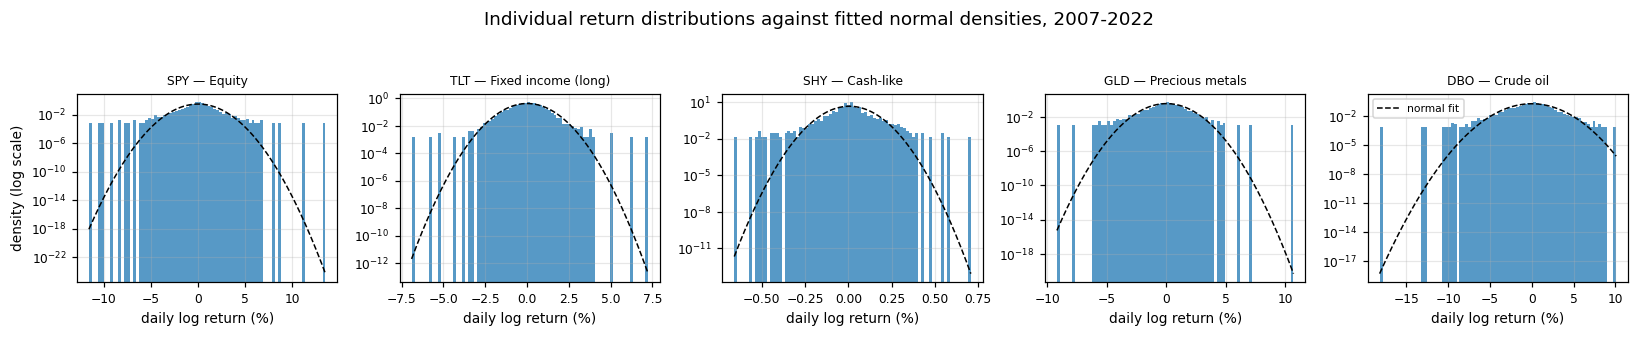

In [ ]:
# Individual distributions: location, dispersion, tails, and cumulative dynamics
summary = pd.DataFrame({
    "asset class": pd.Series(LABELS),
    "annualised mean %": rets.mean() * ANN * 100,
    "annualised volatility %": rets.std() * np.sqrt(ANN) * 100,
    "daily min %": rets.min() * 100,
    "daily max %": rets.max() * 100,
    "skewness": rets.skew(),
    "excess kurtosis": rets.kurtosis(),
    "total return %": (np.exp(rets.sum()) - 1) * 100,
}).round(2)
print("Full common history, 2007-2022")
display(summary)

# The same two moments split by sample period, which is where the regime change shows up.
period = {}
for name, a, b in SPLITS:
    r = rets.loc[a:b]
    period[(name, "mean %")] = r.mean() * ANN * 100
    period[(name, "vol %")] = r.std() * np.sqrt(ANN) * 100
period = pd.DataFrame(period).round(2)
period.columns = pd.MultiIndex.from_tuples(period.columns)
print("Annualised mean and volatility by sample period")
display(period)

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
(px / px.iloc[0] * 100).plot(ax=axes[0], logy=True)
axes[0].set_title("Growth of 100 invested, log scale")
axes[0].set_ylabel("index level (log scale)")
(rets.rolling(21).std() * np.sqrt(ANN) * 100).plot(ax=axes[1], legend=False)
axes[1].set_title("Rolling 21-day annualised volatility")
axes[1].set_ylabel("percent per year")
axes[1].set_xlabel("date")
for ax in axes:
    ax.axvspan(pd.Timestamp(TEST_SAMPLE[0]), pd.Timestamp(TEST_SAMPLE[1]),
               color="grey", alpha=0.12, zorder=0)
axes[0].legend(ncol=5, loc="upper left")
axes[0].text(pd.Timestamp("2018-03-01"), axes[0].get_ylim()[1] * 0.62,
             "test window", fontsize=8, color="dimgrey")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(TICKERS), figsize=(15, 2.9))
for ax, t in zip(axes, TICKERS):
    x = rets[t] * 100
    ax.hist(x, bins=80, density=True, alpha=0.75)
    grid = np.linspace(x.min(), x.max(), 300)
    normal = np.exp(-0.5 * ((grid - x.mean()) / x.std()) ** 2) / (x.std() * np.sqrt(2 * np.pi))
    ax.plot(grid, normal, color="black", linestyle="--", linewidth=1, label="normal fit")
    ax.set_yscale("log")
    ax.set_title(f"{t} — {LABELS[t]}", fontsize=8)
    ax.set_xlabel("daily log return (%)")
axes[0].set_ylabel("density (log scale)")
axes[-1].legend(fontsize=7)
fig.suptitle("Individual return distributions against fitted normal densities, 2007-2022", y=1.04)
plt.tight_layout()
plt.show()

### Joint distributions and dependence

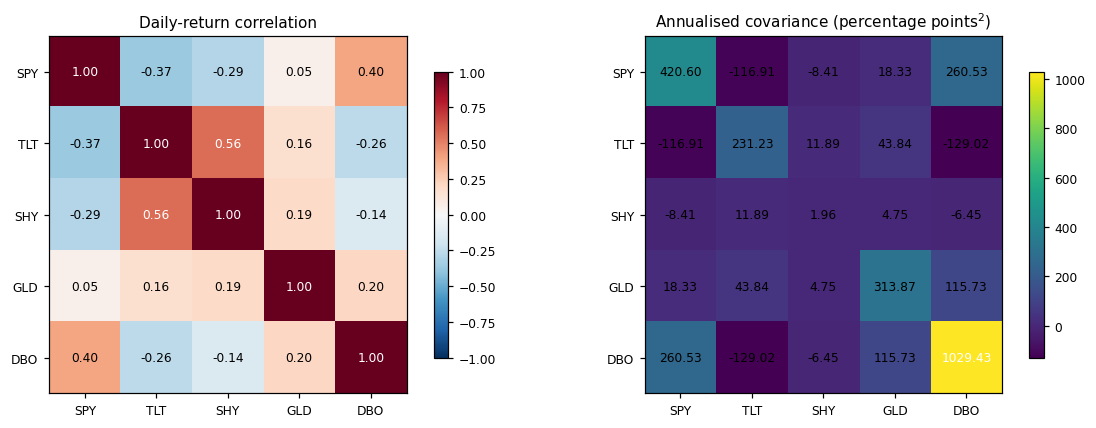

,SPY,TLT,SHY,GLD,DBO
SPY,1.000,-0.375,-0.293,0.050,0.396
TLT,-0.375,1.000,0.558,0.163,-0.264
SHY,-0.293,0.558,1.000,0.191,-0.143
GLD,0.050,0.163,0.191,1.000,0.204
DBO,0.396,-0.264,-0.143,0.204,1.000


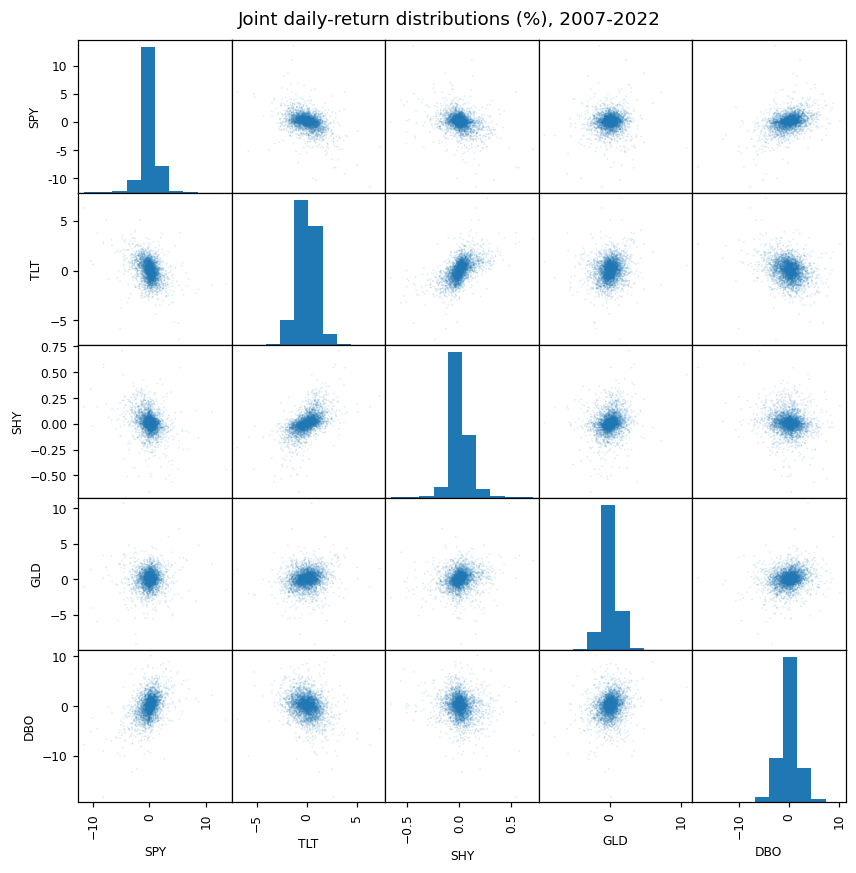

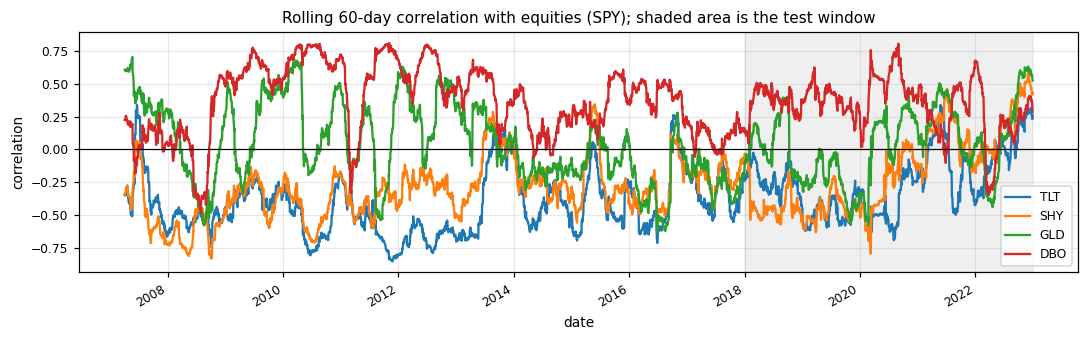

In [ ]:
corr = rets.corr()
cov_ann = rets.cov() * ANN * 10000  # annualised covariance, squared percentage points

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, matrix, title, kwargs in (
    (axes[0], corr, "Daily-return correlation", {"vmin": -1, "vmax": 1, "cmap": "RdBu_r"}),
    (axes[1], cov_ann, "Annualised covariance (percentage points$^2$)", {"cmap": "viridis"}),
):
    im = ax.imshow(matrix.values, **kwargs)
    ax.set_xticks(range(len(TICKERS)), TICKERS)
    ax.set_yticks(range(len(TICKERS)), TICKERS)
    ax.grid(False)
    ax.set_title(title)
    threshold = np.nanmax(np.abs(matrix.values)) * 0.55
    for i in range(len(TICKERS)):
        for j in range(len(TICKERS)):
            value = matrix.iloc[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                    color="white" if abs(value) > threshold else "black", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

display(corr.round(3))

axg = pd.plotting.scatter_matrix(rets * 100, figsize=(9, 9), diagonal="hist",
                                 alpha=0.15, s=5, range_padding=0.08)
for row in axg:
    for a in row:
        a.grid(False)
        a.set_xlabel(a.get_xlabel(), fontsize=8)
        a.set_ylabel(a.get_ylabel(), fontsize=8)
plt.suptitle("Joint daily-return distributions (%), 2007-2022", y=0.91)
plt.show()

fig, ax = plt.subplots(figsize=(10, 3.2))
rets.rolling(60).corr(rets["SPY"]).drop(columns="SPY").plot(ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvspan(pd.Timestamp(TEST_SAMPLE[0]), pd.Timestamp(TEST_SAMPLE[1]),
           color="grey", alpha=0.12, zorder=0)
ax.set_title("Rolling 60-day correlation with equities (SPY); shaded area is the test window")
ax.set_ylabel("correlation")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()

### Stationarity and the representation fed to the models

ADF statistic  ...  reject unit root at 5%
asset series                                       ...                        
SPY   log price (constant)                 -0.028  ...                   False
      log price (constant + trend)         -3.050  ...                   False
      daily log return                    -15.457  ...                    True
      25-day log return                    -8.025  ...                    True
TLT   log price (constant)                 -1.935  ...                   False
      log price (constant + trend)         -1.353  ...                   False
      daily log return                    -12.167  ...                    True
      25-day log return                    -7.682  ...                    True
SHY   log price (constant)                 -4.368  ...                    True
      log price (constant + trend)         -3.120  ...                   False
      daily log return                     -9.662  ...                    True
      25-day log return                    -5.344  ...                    True
GLD   log price (constant)                 -2.587  ...                   False
      log price (constant + trend)         -2.587  ...                   False
      daily log return                    -63.765  ...                    True
      25-day log return                    -7.902  ...                    True
DBO   log price (constant)                 -1.235  ...                   False
      log price (constant + trend)         -1.605  ...                   False
      daily log return                    -66.532  ...                    True
      25-day log return                    -6.474  ...                    True

[20 rows x 4 columns]

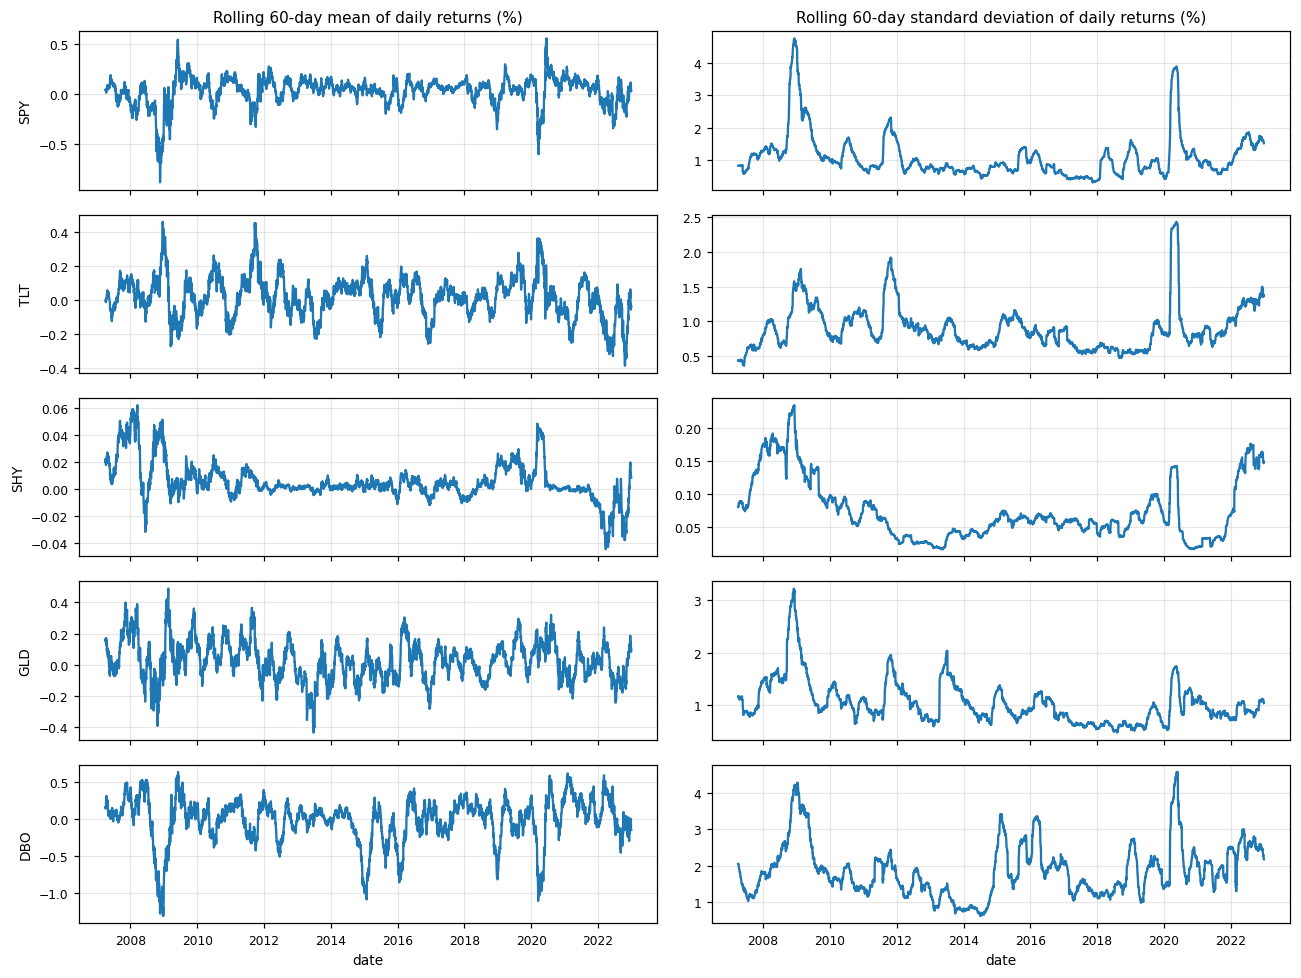

In [ ]:
# ADF test implemented with NumPy only; lag order selected by AIC on a fixed
# effective sample, with MacKinnon (1991) finite-sample critical values.
# "c" includes a constant; "ct" adds a linear trend, which is the right
# specification for a price series that drifts.
_MACKINNON = {
    "c":  {0.01: (-3.43035, -6.5393, -16.786, -79.433),
           0.05: (-2.86154, -2.8903, -4.234, -40.040),
           0.10: (-2.56677, -1.5384, -2.809, 0.0)},
    "ct": {0.01: (-3.95877, -9.0531, -28.428, -134.155),
           0.05: (-3.41049, -4.3904, -9.036, -45.374),
           0.10: (-3.12705, -2.5856, -3.925, -22.380)},
}


def _adf_regress(y, lags, start, trend):
    """OLS for dy_t = g*y_{t-1} + sum_i d_i dy_{t-i} + c (+ b*t); (t-stat, AIC, nobs)."""
    dy = np.diff(y)
    target = dy[start:]
    cols = [y[start:len(y) - 1]]
    cols += [dy[start - i:len(dy) - i] for i in range(1, lags + 1)]
    cols.append(np.ones(len(target)))
    if trend:
        cols.append(np.arange(len(target), dtype=float))
    X = np.column_stack(cols)
    beta, *_ = np.linalg.lstsq(X, target, rcond=None)
    resid = target - X @ beta
    se = np.sqrt(resid @ resid / (len(target) - X.shape[1])
                 * np.diag(np.linalg.pinv(X.T @ X)))
    aic = len(target) * np.log(resid @ resid / len(target)) + 2 * X.shape[1]
    return float(beta[0] / se[0]), float(aic), len(target)


def adf_test(series, regression="c"):
    """Augmented Dickey-Fuller test with AIC-selected lag order."""
    y = np.asarray(series.dropna(), dtype=float)
    trend = regression == "ct"
    maxlag = int(np.ceil(12 * (len(y) / 100) ** 0.25))
    lag = min((_adf_regress(y, k, maxlag, trend)[1], k) for k in range(maxlag + 1))[1]
    stat, _, nobs = _adf_regress(y, lag, lag, trend)
    cv = {a: b0 + b1 / nobs + b2 / nobs ** 2 + b3 / nobs ** 3
          for a, (b0, b1, b2, b3) in _MACKINNON[regression].items()}
    return stat, lag, cv


rows = []
for t in TICKERS:
    for name, values, reg in (
            ("log price (constant)", np.log(px[t]), "c"),
            ("log price (constant + trend)", np.log(px[t]), "ct"),
            ("daily log return", rets[t], "c"),
            (f"{HORIZON}-day log return", rets[t].rolling(HORIZON).sum(), "c")):
        stat, lag, cv = adf_test(values, reg)
        rows.append({"asset": t, "series": name, "ADF statistic": stat,
                     "selected lags": lag, "5% critical value": cv[0.05],
                     "reject unit root at 5%": stat < cv[0.05]})
adf_results = pd.DataFrame(rows).set_index(["asset", "series"])
display(adf_results.round(3))

fig, axes = plt.subplots(len(TICKERS), 2, figsize=(12, 9), sharex=True)
for i, t in enumerate(TICKERS):
    axes[i, 0].plot(rets[t].rolling(60).mean() * 100)
    axes[i, 1].plot(rets[t].rolling(60).std() * 100)
    axes[i, 0].set_ylabel(t)
axes[0, 0].set_title("Rolling 60-day mean of daily returns (%)")
axes[0, 1].set_title("Rolling 60-day standard deviation of daily returns (%)")
for ax in axes[-1]:
    ax.set_xlabel("date")
plt.tight_layout()
plt.show()

## Shared training infrastructure

In [ ]:
class Layer:
    """Minimal interface shared by every layer in the NumPy models."""
    trainable = False

    def forward(self, x, train=True):
        raise NotImplementedError

    def backward(self, g):
        raise NotImplementedError

    def params_and_grads(self):
        return []


class Dense(Layer):
    trainable = True

    def __init__(self, n_in, n_out, rng, gain=2.0):
        self.W = rng.normal(0.0, np.sqrt(gain / n_in), size=(n_in, n_out))
        self.b = np.zeros(n_out)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    def forward(self, x, train=True):
        self.x = x
        return x @ self.W + self.b

    def backward(self, g):
        self.dW[...] = self.x.T @ g
        self.db[...] = g.sum(axis=0)
        return g @ self.W.T

    def params_and_grads(self):
        return [(self.W, self.dW), (self.b, self.db)]


class ReLU(Layer):
    def forward(self, x, train=True):
        self.mask = x > 0
        return x * self.mask

    def backward(self, g):
        return g * self.mask


class Tanh(Layer):
    def forward(self, x, train=True):
        self.out = np.tanh(x)
        return self.out

    def backward(self, g):
        return g * (1.0 - self.out ** 2)


class Dropout(Layer):
    def __init__(self, p, rng):
        self.p, self.rng = p, rng

    def forward(self, x, train=True):
        if not train or self.p <= 0:
            self.mask = None
            return x
        self.mask = (self.rng.random(x.shape) >= self.p) / (1.0 - self.p)
        return x * self.mask

    def backward(self, g):
        return g if self.mask is None else g * self.mask


class Adam:
    """Adam with decoupled weight decay and global gradient-norm clipping."""

    def __init__(self, params, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8, wd=0.0):
        self.p = params
        self.lr, self.b1, self.b2, self.eps, self.wd = lr, b1, b2, eps, wd
        self.m = [np.zeros_like(w) for w, _ in params]
        self.v = [np.zeros_like(w) for w, _ in params]
        self.t = 0

    def step(self, clip=5.0):
        self.t += 1
        total = np.sqrt(sum(float((gr ** 2).sum()) for _, gr in self.p))
        scale = clip / (total + 1e-12) if clip and total > clip else 1.0
        b1t, b2t = 1 - self.b1 ** self.t, 1 - self.b2 ** self.t
        for k, (w, gr) in enumerate(self.p):
            g = gr * scale + self.wd * w
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * g
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * g * g
            w -= self.lr * (self.m[k] / b1t) / (np.sqrt(self.v[k] / b2t) + self.eps)


class Model:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x, train=True):
        for L in self.layers:
            x = L.forward(x, train)
        return x

    def backward(self, g):
        for L in reversed(self.layers):
            g = L.backward(g)
        return g

    def params(self):
        out = []
        for L in self.layers:
            out.extend(L.params_and_grads())
        return out

    def get_weights(self):
        return [w.copy() for w, _ in self.params()]

    def set_weights(self, ws):
        for (w, _), src in zip(self.params(), ws):
            w[...] = src

    def predict(self, x, batch=256):
        return np.concatenate([self.forward(x[i:i + batch], train=False)
                               for i in range(0, len(x), batch)], axis=0)

    def fit(self, Xtr, Ytr, Xva, Yva, *, epochs, batch, lr, patience, wd, seed):
        """Mini-batch Adam on mean squared error, early stopping on validation MSE."""
        rng = np.random.default_rng(seed)
        opt = Adam(self.params(), lr=lr, wd=wd)
        best, best_w, bad, hist = np.inf, self.get_weights(), 0, []
        for _ in range(epochs):
            order = rng.permutation(len(Xtr))
            for s in range(0, len(Xtr), batch):
                xb, yb = Xtr[order[s:s + batch]], Ytr[order[s:s + batch]]
                pred = self.forward(xb, train=True)
                self.backward(2.0 * (pred - yb) / yb.size)
                opt.step()
            tl = float(np.mean((self.predict(Xtr) - Ytr) ** 2))
            vl = float(np.mean((self.predict(Xva) - Yva) ** 2))
            hist.append((tl, vl))
            if vl < best - 1e-9:
                best, best_w, bad = vl, self.get_weights(), 0
            else:
                bad += 1
                if bad >= patience:
                    break
        self.set_weights(best_w)
        self.history, self.best_val, self.epochs_run = hist, best, len(hist)
        return self


print("layers, optimiser and training loop ready")

layers, optimiser and training loop ready


### Gradient-check utility

Every architecture verifies its analytic gradients against central finite differences before
it is trained. The check is run in each model's own section.

In [ ]:
rng_chk = np.random.default_rng(0)


def gradcheck(model, x, y, name):
    def loss():
        return float(np.mean((model.forward(x, train=False) - y) ** 2))

    p = model.forward(x, train=False)
    model.backward(2.0 * (p - y) / y.size)
    worst = 0.0
    for w, gr in model.params():
        fw, fg = w.ravel(), gr.ravel()
        for i in rng_chk.choice(fw.size, size=min(12, fw.size), replace=False):
            old, eps = fw[i], 1e-6
            fw[i] = old + eps; lp = loss()
            fw[i] = old - eps; lm = loss()
            fw[i] = old
            num = (lp - lm) / (2 * eps)
            worst = max(worst, abs(num - fg[i]) / max(1e-8, abs(num) + abs(fg[i])))
    print(f"{name:22s} max relative gradient error = {worst:.2e}   "
          f"{'PASS' if worst < 2e-4 else 'FAIL'}")

## Sample construction, splits and training protocol

In [ ]:
def build_samples(returns, lookback, horizon):
    """Sliding windows of past daily log returns paired with the h-day ahead log return.

    Sample t uses returns[t-lookback+1 .. t] as inputs and
    log(P_{t+h}/P_t) = sum(returns[t+1 .. t+h]) as the target, so inputs and target
    never overlap. Returns inputs, targets, forecast-origin dates, and the first and
    last date covered by each target window.
    """
    R, dates = returns.values, returns.index
    idx = np.arange(lookback - 1, len(R) - horizon)
    X = np.stack([R[i - lookback + 1:i + 1] for i in idx], axis=0)      # (m, L, k)
    Y = np.stack([R[i + 1:i + 1 + horizon].sum(axis=0) for i in idx])   # (m, k)
    return X, Y, dates[idx], dates[idx + 1], dates[idx + horizon]


def metrics(y_true, y_pred, y_train_mean):
    """RMSE, MAE, out-of-sample R^2 against the training mean, hit rate and IC."""
    e = y_pred - y_true
    ss_tot = float(np.sum((y_true - y_train_mean) ** 2))
    return {"RMSE": float(np.sqrt(np.mean(e ** 2))),
            "MAE": float(np.mean(np.abs(e))),
            "R2": 1.0 - float(np.sum(e ** 2)) / ss_tot,
            "HitRate": float(np.mean(np.sign(y_pred) == np.sign(y_true))),
            "IC": float(np.corrcoef(y_pred, y_true)[0, 1]) if np.std(y_pred) > 1e-12 else 0.0}


X_all, Y_all, dates, target_start, target_end = build_samples(rets, LOOKBACK, HORIZON)
keep = ((target_start >= pd.Timestamp(SPLITS[0][1]))
        & (target_end <= pd.Timestamp(SPLITS[-1][2])))
X_all, Y_all, dates = X_all[keep], Y_all[keep], dates[keep]
target_start, target_end = target_start[keep], target_end[keep]

# A sample belongs to a split only when its complete target window lies inside it.
masks = {n: (target_start >= pd.Timestamp(a)) & (target_end <= pd.Timestamp(b))
         for n, a, b in SPLITS}

print(f"input window {X_all.shape[1]} days x {X_all.shape[2]} assets  ->  "
      f"{Y_all.shape[1]} targets per sample")
for n in ("train", "val", "test"):
    m = masks[n]
    print(f"{n:5s} {m.sum():5d} samples   target windows "
          f"{target_start[m][0].date()} -> {target_end[m][-1].date()}   "
          f"(forecast origins {dates[m][0].date()} -> {dates[m][-1].date()})")
print(f"unassigned to any split (embargoed at the boundaries): "
      f"{len(dates) - sum(int(masks[n].sum()) for n in masks)}")

input window 30 days x 5 assets  ->  5 targets per sample
train  1957 samples   target windows 2007-02-21 -> 2014-12-31   (forecast origins 2007-02-20 -> 2014-11-24)
val     731 samples   target windows 2015-01-02 -> 2017-12-29   (forecast origins 2014-12-31 -> 2017-11-22)
test   1235 samples   target windows 2018-01-02 -> 2022-12-30   (forecast origins 2017-12-29 -> 2022-11-23)
unassigned to any split (embargoed at the boundaries): 48


In [ ]:
def zfit(a):
    return float(a.mean()), float(a.std() + 1e-12)


def zfeatures(x, masks):
    """Standardise using training-split statistics only."""
    mu, sd = zfit(x[masks["train"]])
    return (x - mu) / sd


def train_ensemble(builder, data, *, lr, epochs, patience, batch, wd, tag):
    """Fit one model per seed and return the seed-averaged predictions."""
    (Xtr, Ytr), (Xva, Yva), (Xte, Yte) = data
    preds = {"train": [], "val": [], "test": []}
    hists, total_epochs, t0 = [], 0, time.time()
    for s in SEEDS:
        m = builder(np.random.default_rng(1000 + s))
        m.fit(Xtr, Ytr, Xva, Yva, epochs=epochs, batch=batch, lr=lr,
              patience=patience, wd=wd, seed=s)
        for k, X in (("train", Xtr), ("val", Xva), ("test", Xte)):
            preds[k].append(m.predict(X))
        hists.append(m.history)
        total_epochs += m.epochs_run
    print(f"  {tag:14s} {total_epochs:4d} epochs over {len(SEEDS)} seeds, "
          f"{time.time() - t0:5.0f}s")
    return {k: np.mean(np.stack(v, 0), 0) for k, v in preds.items()}, hists


def run_single_asset_family(fam, make_features, builder_for, hp):
    """Train one single-output model per ETF and store its metrics and test predictions."""
    RESULTS[fam] = {s: {} for s in ("train", "val", "test")}
    PRED_TEST[fam] = {}
    print(f"--- {fam}")
    for j, t in enumerate(TICKERS):
        Xf = make_features(X_all[:, :, j], masks)
        ymu, ysd = zfit(Y_all[masks["train"], j])
        Ys = ((Y_all[:, j] - ymu) / ysd)[:, None]
        data = tuple((Xf[masks[s]], Ys[masks[s]]) for s in ("train", "val", "test"))
        pred, hists = train_ensemble(builder_for, data, tag=f"{fam}/{t}", **hp)
        if t == "SPY":
            CURVES[fam] = hists[0]
        ytr_mean = float(Y_all[masks["train"], j].mean())
        for s in ("train", "val", "test"):
            p = pred[s].ravel() * ysd + ymu
            y = Y_all[masks[s], j]
            RESULTS[fam][s][t] = metrics(y, p, ytr_mean)
            if s == "test":
                PRED_TEST[fam][t] = p


def report(fam, splits=("train", "val", "test")):
    """Tidy metric table for one architecture."""
    df = pd.DataFrame({(s, t): RESULTS[fam][s][t]
                       for s in splits for t in TICKERS}).T.round(4)
    df.index.names = ["sample", "ETF"]
    return df


RESULTS, PRED_TEST, CURVES = {}, {}, {}
print("training helpers ready")

training helpers ready


## Step 2 — Multi-layer perceptron (MLP)

In [ ]:
def build_mlp(n_in, n_out, rng):
    return Model([Dense(n_in, 32, rng), ReLU(), Dropout(0.20, rng),
                  Dense(32, 16, rng), ReLU(), Dense(16, n_out, rng, gain=1.0)])


gradcheck(build_mlp(6, 2, rng_chk), rng_chk.normal(size=(7, 6)),
          rng_chk.normal(size=(7, 2)), "MLP layers")

run_single_asset_family(
    "MLP",
    zfeatures,
    lambda rng: build_mlp(LOOKBACK, 1, rng),
    dict(lr=1e-3, epochs=400, patience=40, batch=32, wd=1e-4))
report("MLP")

MLP layers             max relative gradient error = 2.04e-08   PASS
--- MLP
  MLP/SPY         171 epochs over 3 seeds,     1s
  MLP/TLT         170 epochs over 3 seeds,     1s
  MLP/SHY         191 epochs over 3 seeds,     2s
  MLP/GLD         149 epochs over 3 seeds,     1s
  MLP/DBO         136 epochs over 3 seeds,     1s


RMSE     MAE      R2  HitRate      IC
sample ETF                                         
train  SPY  0.0542  0.0387  0.1355   0.6960  0.4909
       TLT  0.0417  0.0310  0.1499   0.6346  0.5588
       SHY  0.0036  0.0024  0.4033   0.6909  0.6966
       GLD  0.0569  0.0456  0.0940   0.6050  0.4025
       DBO  0.0935  0.0693  0.1104   0.5488  0.3699
val    SPY  0.0327  0.0234  0.0128   0.7127  0.0387
       TLT  0.0367  0.0275  0.0185   0.5595  0.0985
       SHY  0.0026  0.0020  0.2690   0.5609 -0.0712
       GLD  0.0448  0.0341  0.0094   0.4843  0.0661
       DBO  0.0952  0.0758 -0.0569   0.4870  0.0048
test   SPY  0.0632  0.0441 -0.0525   0.6227 -0.1486
       TLT  0.0478  0.0369  0.0130   0.5085  0.0668
       SHY  0.0053  0.0034  0.0503   0.5822  0.0814
       GLD  0.0405  0.0322 -0.0071   0.5231  0.0260
       DBO  0.1121  0.0871 -0.0366   0.4494  0.0241

## Step 3 — Convolutional network on Gramian Angular Fields (CNN-GAF)


GAF tensor per sample: (2, 30, 30)  (channels, lookback, lookback)


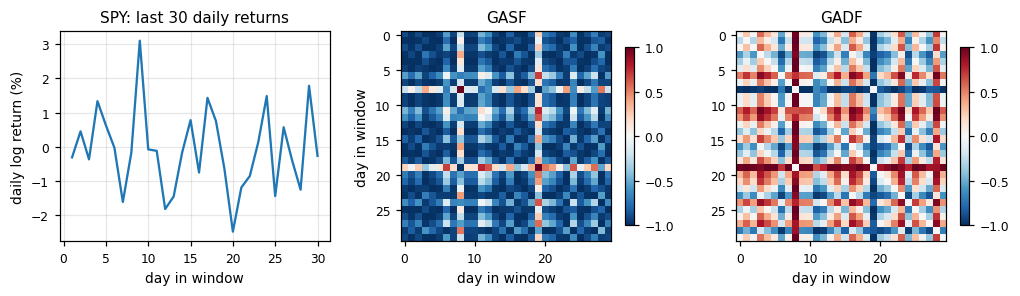

In [ ]:
class Flatten(Layer):
    def forward(self, x, train=True):
        self.shape = x.shape
        return x.reshape(x.shape[0], -1)

    def backward(self, g):
        return g.reshape(self.shape)


def _im2col(x, kh, kw):
    """Convert NCHW image patches to columns using a no-copy strided view."""
    N, C, H, W = x.shape
    oh, ow = H - kh + 1, W - kw + 1
    s = x.strides
    view = np.lib.stride_tricks.as_strided(
        x, shape=(N, C, kh, kw, oh, ow),
        strides=(s[0], s[1], s[2], s[3], s[2], s[3]), writeable=False)
    return view.reshape(N, C * kh * kw, oh * ow), oh, ow


class Conv2D(Layer):
    """Valid-padded 2-D convolution for NCHW tensors."""
    trainable = True

    def __init__(self, c_in, c_out, k, rng):
        self.W = rng.normal(0.0, np.sqrt(2.0 / (c_in * k * k)), size=(c_out, c_in, k, k))
        self.b = np.zeros(c_out)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self.k, self.c_in, self.c_out = k, c_in, c_out

    def forward(self, x, train=True):
        self.x_shape = x.shape
        self.cols, self.oh, self.ow = _im2col(x, self.k, self.k)
        out = np.matmul(self.W.reshape(self.c_out, -1), self.cols) + self.b[None, :, None]
        return out.reshape(x.shape[0], self.c_out, self.oh, self.ow)

    def backward(self, g):
        N, C, H, W = self.x_shape
        k = self.k
        gf = g.reshape(N, self.c_out, -1)
        self.dW[...] = np.tensordot(gf, self.cols, axes=([0, 2], [0, 2])).reshape(self.W.shape)
        self.db[...] = gf.sum(axis=(0, 2))
        dcols = np.matmul(self.W.reshape(self.c_out, -1).T, gf)
        dcols = dcols.reshape(N, C, k, k, self.oh, self.ow)
        dx = np.zeros((N, C, H, W))
        for i in range(k):
            for j in range(k):
                dx[:, :, i:i + self.oh, j:j + self.ow] += dcols[:, :, i, j]
        return dx

    def params_and_grads(self):
        return [(self.W, self.dW), (self.b, self.db)]


class MaxPool2D(Layer):
    def __init__(self, size=2):
        self.s = size

    def forward(self, x, train=True):
        N, C, H, W = x.shape
        s = self.s
        H2, W2 = (H // s) * s, (W // s) * s
        r = x[:, :, :H2, :W2].reshape(N, C, H2 // s, s, W2 // s, s)
        r = r.transpose(0, 1, 2, 4, 3, 5).reshape(N, C, H2 // s, W2 // s, s * s)
        self.arg, self.in_shape, self.crop = r.argmax(axis=-1), x.shape, (H2, W2)
        return r.max(axis=-1)

    def backward(self, g):
        N, C, H, W = self.in_shape
        s, (H2, W2) = self.s, self.crop
        flat = np.zeros(self.arg.shape + (s * s,))
        idx = np.indices(self.arg.shape)
        flat[idx[0], idx[1], idx[2], idx[3], self.arg] = g
        flat = flat.reshape(N, C, H2 // s, W2 // s, s, s).transpose(0, 1, 2, 4, 3, 5)
        dx = np.zeros((N, C, H, W))
        dx[:, :, :H2, :W2] = flat.reshape(N, C, H2, W2)
        return dx


def gaf(window):
    """Encode one return window as the summation and difference Gramian angular fields."""
    x = np.asarray(window, dtype=float)
    lo, hi = x.min(), x.max()
    xs = np.zeros_like(x) if hi - lo < 1e-12 else (2 * x - hi - lo) / (hi - lo)
    xs = np.clip(xs, -1.0, 1.0)
    s = np.sqrt(np.clip(1.0 - xs ** 2, 0.0, None))
    return np.stack([np.outer(xs, xs) - np.outer(s, s),     # GASF
                     np.outer(s, xs) - np.outer(xs, s)])    # GADF


example = rets["SPY"].values[-LOOKBACK:]
g = gaf(example)
fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.8))
axes[0].plot(np.arange(1, LOOKBACK + 1), example * 100)
axes[0].set_title("SPY: last 30 daily returns")
axes[0].set_xlabel("day in window"); axes[0].set_ylabel("daily log return (%)")
for k, (name, matrix) in enumerate((("GASF", g[0]), ("GADF", g[1]))):
    im = axes[k + 1].imshow(matrix, cmap="RdBu_r", vmin=-1, vmax=1)
    axes[k + 1].set_title(name)
    axes[k + 1].set_xlabel("day in window"); axes[k + 1].grid(False)
    fig.colorbar(im, ax=axes[k + 1], shrink=0.85)
axes[1].set_ylabel("day in window")
plt.tight_layout(); plt.show()
print(f"GAF tensor per sample: {g.shape}  (channels, lookback, lookback)")

In [ ]:
def build_cnn(rng, flat=16 * 6 * 6):
    return Model([Conv2D(2, 8, 3, rng), ReLU(), MaxPool2D(2),
                  Conv2D(8, 16, 3, rng), ReLU(), MaxPool2D(2), Flatten(),
                  Dense(flat, 24, rng), ReLU(), Dropout(0.20, rng),
                  Dense(24, 1, rng, gain=1.0)])


gradcheck(Model([Conv2D(2, 3, 3, rng_chk), ReLU(), MaxPool2D(2),
                 Conv2D(3, 4, 3, rng_chk), ReLU(), Flatten(),
                 Dense(4 * 2 * 2, 1, rng_chk)]),
          rng_chk.normal(size=(5, 2, 11, 11)), rng_chk.normal(size=(5, 1)),
          "CNN layers")

run_single_asset_family(
    "CNN-GAF",
    lambda x, m: np.stack([gaf(w) for w in x]),
    build_cnn,
    dict(lr=8e-4, epochs=250, patience=30, batch=32, wd=1e-4))
report("CNN-GAF")

CNN layers             max relative gradient error = 4.86e-09   PASS
--- CNN-GAF
  CNN-GAF/SPY     100 epochs over 3 seeds,   158s
  CNN-GAF/TLT     101 epochs over 3 seeds,   160s
  CNN-GAF/SHY     107 epochs over 3 seeds,   165s
  CNN-GAF/GLD     103 epochs over 3 seeds,   165s
  CNN-GAF/DBO     103 epochs over 3 seeds,   156s


RMSE     MAE      R2  HitRate      IC
sample ETF                                         
train  SPY  0.0573  0.0407  0.0367   0.6617  0.3273
       TLT  0.0443  0.0324  0.0418   0.5994  0.3093
       SHY  0.0042  0.0029  0.1665   0.6929  0.5725
       GLD  0.0576  0.0456  0.0724   0.6065  0.3613
       DBO  0.0962  0.0702  0.0581   0.5687  0.3971
val    SPY  0.0327  0.0238  0.0080   0.7127  0.0623
       TLT  0.0364  0.0276  0.0338   0.5527  0.1290
       SHY  0.0028  0.0023  0.1231   0.5513  0.0319
       GLD  0.0435  0.0336  0.0684   0.4856  0.2474
       DBO  0.0918  0.0723  0.0180   0.5294  0.1222
test   SPY  0.0616  0.0435  0.0007   0.6664  0.0315
       TLT  0.0479  0.0368  0.0101   0.4947  0.0076
       SHY  0.0053  0.0037  0.0493   0.5822  0.0710
       GLD  0.0412  0.0327 -0.0380   0.4988 -0.1136
       DBO  0.1107  0.0862 -0.0108   0.4405 -0.0033

## Step 4 — Single-output LSTM

In [ ]:
def _sigmoid(x):
    """Numerically stable logistic function used by the LSTM gates."""
    out = np.empty_like(x)
    pos = x >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
    ex = np.exp(x[~pos])
    out[~pos] = ex / (1.0 + ex)
    return out


class LSTM(Layer):
    """Last-state LSTM with gate order [input, forget, output, candidate]."""
    trainable = True

    def __init__(self, d_in, d_hid, rng, forget_bias=1.0):
        lim = np.sqrt(1.0 / d_hid)
        self.Wx = rng.uniform(-lim, lim, size=(d_in, 4 * d_hid))
        self.Wh = rng.uniform(-lim, lim, size=(d_hid, 4 * d_hid))
        self.b = np.zeros(4 * d_hid)
        self.b[d_hid:2 * d_hid] = forget_bias      # start with the forget gate open
        self.dWx = np.zeros_like(self.Wx)
        self.dWh = np.zeros_like(self.Wh)
        self.db = np.zeros_like(self.b)
        self.H = d_hid

    def forward(self, x, train=True):
        N, T, _ = x.shape
        H = self.H
        self.x = x
        self.h = np.zeros((N, T + 1, H))
        self.c = np.zeros((N, T + 1, H))
        self.gates = np.zeros((N, T, 4 * H))
        self.ct = np.zeros((N, T, H))
        for t in range(T):
            z = x[:, t] @ self.Wx + self.h[:, t] @ self.Wh + self.b
            i, f, o = (_sigmoid(z[:, k * H:(k + 1) * H]) for k in range(3))
            gcand = np.tanh(z[:, 3 * H:])
            self.gates[:, t] = np.concatenate([i, f, o, gcand], axis=1)
            self.c[:, t + 1] = f * self.c[:, t] + i * gcand
            self.ct[:, t] = np.tanh(self.c[:, t + 1])
            self.h[:, t + 1] = o * self.ct[:, t]
        return self.h[:, T]

    def backward(self, g_last):
        N, T, _ = self.x.shape
        H = self.H
        self.dWx[...] = self.dWh[...] = self.db[...] = 0.0
        dh, dc = g_last.copy(), np.zeros((N, H))
        dx = np.zeros_like(self.x)
        for t in range(T - 1, -1, -1):
            i, f, o, gcand = (self.gates[:, t, k * H:(k + 1) * H] for k in range(4))
            ct = self.ct[:, t]
            do = dh * ct
            dc = dc + dh * o * (1.0 - ct ** 2)
            di, dg, df = dc * gcand, dc * i, dc * self.c[:, t]
            dc_prev = dc * f
            dz = np.concatenate([di * i * (1 - i), df * f * (1 - f),
                                 do * o * (1 - o), dg * (1 - gcand ** 2)], axis=1)
            self.dWx += self.x[:, t].T @ dz
            self.dWh += self.h[:, t].T @ dz
            self.db += dz.sum(axis=0)
            dx[:, t] = dz @ self.Wx.T
            dh, dc = dz @ self.Wh.T, dc_prev
        return dx

    def params_and_grads(self):
        return [(self.Wx, self.dWx), (self.Wh, self.dWh), (self.b, self.db)]


def build_single_output_lstm(rng):
    return Model([LSTM(1, 24, rng), Tanh(), Dense(24, 1, rng, gain=1.0)])


gradcheck(Model([LSTM(3, 6, rng_chk), Dense(6, 1, rng_chk)]),
          rng_chk.normal(size=(4, 7, 3)), rng_chk.normal(size=(4, 1)),
          "LSTM layers (BPTT)")

run_single_asset_family(
    "LSTM",
    lambda x, m: zfeatures(x, m)[:, :, None],
    build_single_output_lstm,
    dict(lr=5e-3, epochs=300, patience=35, batch=32, wd=1e-4))
report("LSTM")

LSTM layers (BPTT)     max relative gradient error = 8.06e-08   PASS
--- LSTM
  LSTM/SPY        118 epochs over 3 seeds,    66s
  LSTM/TLT        128 epochs over 3 seeds,    73s
  LSTM/SHY        119 epochs over 3 seeds,    63s
  LSTM/GLD        117 epochs over 3 seeds,    64s
  LSTM/DBO        112 epochs over 3 seeds,    64s


RMSE     MAE      R2  HitRate      IC
sample ETF                                         
train  SPY  0.0520  0.0385  0.2060   0.6689  0.4885
       TLT  0.0421  0.0312  0.1367   0.6127  0.4307
       SHY  0.0038  0.0026  0.3146   0.6597  0.5661
       GLD  0.0570  0.0455  0.0914   0.5192  0.3224
       DBO  0.0934  0.0688  0.1116   0.6137  0.3746
val    SPY  0.0318  0.0229  0.0633   0.7250  0.2245
       TLT  0.0358  0.0272  0.0667   0.5732  0.2121
       SHY  0.0024  0.0019  0.3753   0.5472  0.1180
       GLD  0.0441  0.0331  0.0397   0.5130  0.1288
       DBO  0.0956  0.0763 -0.0648   0.4337  0.0296
test   SPY  0.0672  0.0454 -0.1878   0.6000 -0.1935
       TLT  0.0478  0.0368  0.0168   0.5150  0.0818
       SHY  0.0059  0.0039 -0.1812   0.5514 -0.1324
       GLD  0.0407  0.0321 -0.0131   0.4858  0.0614
       DBO  0.1081  0.0828  0.0359   0.5733  0.1669

## Step 5 — Cross-asset multi-output LSTM

In [ ]:
def build_multi_output_lstm(rng):
    return Model([LSTM(len(TICKERS), 48, rng), Tanh(),
                  Dense(48, len(TICKERS), rng, gain=1.0)])


gradcheck(Model([LSTM(5, 8, rng_chk), Tanh(), Dense(8, 5, rng_chk)]),
          rng_chk.normal(size=(6, 9, 5)), rng_chk.normal(size=(6, 5)),
          "multi-output LSTM")

print("--- LSTM-MO")
xmu = X_all[masks["train"]].mean(axis=(0, 1))          # per-asset scaling
xsd = X_all[masks["train"]].std(axis=(0, 1)) + 1e-12
ymu = Y_all[masks["train"]].mean(axis=0)
ysd = Y_all[masks["train"]].std(axis=0) + 1e-12
Xz, Ys = (X_all - xmu) / xsd, (Y_all - ymu) / ysd
data = tuple((Xz[masks[s]], Ys[masks[s]]) for s in ("train", "val", "test"))

pred, hists = train_ensemble(build_multi_output_lstm, data, lr=4e-3, epochs=300,
                             patience=35, batch=32, wd=1e-4, tag="LSTM-MO")
CURVES["LSTM-MO"] = hists[0]
RESULTS["LSTM-MO"] = {s: {} for s in ("train", "val", "test")}
PRED_TEST["LSTM-MO"] = {}
for s in ("train", "val", "test"):
    p = pred[s] * ysd + ymu
    for j, t in enumerate(TICKERS):
        RESULTS["LSTM-MO"][s][t] = metrics(Y_all[masks[s], j], p[:, j],
                                           float(Y_all[masks["train"], j].mean()))
        if s == "test":
            PRED_TEST["LSTM-MO"][t] = p[:, j]
report("LSTM-MO")

multi-output LSTM      max relative gradient error = 1.56e-06   PASS
--- LSTM-MO
  LSTM-MO         110 epochs over 3 seeds,   126s


RMSE     MAE      R2  HitRate      IC
sample ETF                                         
train  SPY  0.0480  0.0358  0.3244   0.6822  0.5985
       TLT  0.0379  0.0290  0.3004   0.6811  0.5949
       SHY  0.0035  0.0024  0.4377   0.6990  0.6687
       GLD  0.0521  0.0403  0.2407   0.6714  0.5141
       DBO  0.0786  0.0589  0.3707   0.6648  0.6255
val    SPY  0.0332  0.0241 -0.0234   0.6389  0.0807
       TLT  0.0364  0.0275  0.0331   0.5404  0.1347
       SHY  0.0025  0.0020  0.3270   0.5595 -0.0733
       GLD  0.0472  0.0358 -0.0991   0.4993 -0.0550
       DBO  0.0951  0.0753 -0.0543   0.4747 -0.0243
test   SPY  0.0607  0.0424  0.0286   0.6332  0.1761
       TLT  0.0480  0.0364  0.0072   0.5085  0.0540
       SHY  0.0053  0.0034  0.0245   0.5927  0.0191
       GLD  0.0431  0.0342 -0.1385   0.5020  0.0165
       DBO  0.1077  0.0845  0.0437   0.5490  0.1950

In [ ]:
# Step 5: does pooling the five tasks help or hurt, asset by asset?
single_vs_multi = pd.DataFrame({
    "asset class": pd.Series(LABELS),
    "single-output RMSE %": [RESULTS["LSTM"]["test"][t]["RMSE"] * 100 for t in TICKERS],
    "multi-output RMSE %": [RESULTS["LSTM-MO"]["test"][t]["RMSE"] * 100 for t in TICKERS],
    "single-output R2": [RESULTS["LSTM"]["test"][t]["R2"] for t in TICKERS],
    "multi-output R2": [RESULTS["LSTM-MO"]["test"][t]["R2"] for t in TICKERS],
}, index=TICKERS)
single_vs_multi["RMSE change %"] = (
    single_vs_multi["multi-output RMSE %"] / single_vs_multi["single-output RMSE %"] - 1) * 100
single_vs_multi.round(3)

,asset class,single-output RMSE %,multi-output RMSE %,single-output R2,multi-output R2,RMSE change %
SPY,Equity,6.715,6.072,-0.188,0.029,-9.570
TLT,Fixed income (long),4.775,4.799,0.017,0.007,0.486
SHY,Cash-like,0.587,0.533,-0.181,0.024,-9.121
GLD,Precious metals,4.065,4.309,-0.013,-0.138,6.010
DBO,Crude oil,10.812,10.768,0.036,0.044,-0.405


## Comparing the four architectures

In [ ]:
FAMS = ["MLP", "CNN-GAF", "LSTM", "LSTM-MO"]


def grid(metric, split):
    df = pd.DataFrame({f: {t: RESULTS[f][split][t][metric] for t in TICKERS}
                       for f in FAMS}).T
    df["mean"] = df.mean(axis=1)
    return df.round(3)


# Directional accuracy only means something against the unconditional base rate:
# the share of 25-day windows in which the asset actually rose.
base_rate = pd.Series({t: float((Y_all[masks["test"], j] > 0).mean())
                       for j, t in enumerate(TICKERS)})

for split, metric, title in (("train", "R2", "In-sample R^2 (training split)"),
                             ("val", "R2", "Validation R^2"),
                             ("test", "R2", "Out-of-sample R^2 (test split)"),
                             ("test", "HitRate", "Out-of-sample directional accuracy"),
                             ("test", "IC", "Out-of-sample information coefficient")):
    g = grid(metric, split)
    if metric == "HitRate":
        g.loc["always-up base rate"] = list(base_rate.round(3)) + [round(base_rate.mean(), 3)]
    print(f"\n{title}\n" + g.to_string())


In-sample R^2 (training split)
           SPY    TLT    SHY    GLD    DBO   mean
MLP      0.136  0.150  0.403  0.094  0.110  0.179
CNN-GAF  0.037  0.042  0.166  0.072  0.058  0.075
LSTM     0.206  0.137  0.315  0.091  0.112  0.172
LSTM-MO  0.324  0.300  0.438  0.241  0.371  0.335

Validation R^2
           SPY    TLT    SHY    GLD    DBO   mean
MLP      0.013  0.019  0.269  0.009 -0.057  0.051
CNN-GAF  0.008  0.034  0.123  0.068  0.018  0.050
LSTM     0.063  0.067  0.375  0.040 -0.065  0.096
LSTM-MO -0.023  0.033  0.327 -0.099 -0.054  0.037

Out-of-sample R^2 (test split)
           SPY    TLT    SHY    GLD    DBO   mean
MLP     -0.052  0.013  0.050 -0.007 -0.037 -0.007
CNN-GAF  0.001  0.010  0.049 -0.038 -0.011  0.002
LSTM    -0.188  0.017 -0.181 -0.013  0.036 -0.066
LSTM-MO  0.029  0.007  0.024 -0.138  0.044 -0.007

Out-of-sample directional accuracy
                       SPY    TLT    SHY    GLD    DBO   mean
MLP                  0.623  0.509  0.582  0.523  0.449  0.537
CNN-GAF   

## Step 6 — Tactical allocation and backtest


In [ ]:
def weights_from_pred(p, mode):
    w = np.zeros(len(TICKERS))
    order = np.argsort(p)
    if mode == "ls":
        w[order[-2:]], w[order[:2]] = 0.25, -0.25
    else:
        w[order[-3:]] = 1.0 / 3.0
    return w


def perf(daily):
    eq = np.cumprod(1.0 + daily)
    vol = float(np.std(daily) * np.sqrt(ANN))
    cagr = float(eq[-1] ** (ANN / len(daily)) - 1.0)
    return {"Total return": float(eq[-1] - 1), "CAGR": cagr, "Ann. vol": vol,
            "Sharpe": float(cagr / vol) if vol > 1e-12 else 0.0,
            "Max drawdown": float((eq / np.maximum.accumulate(eq) - 1.0).min()),
            "equity": eq}


def backtest(pred, daily, mode, cost_bps=COST_BPS):
    """Rebalance every HORIZON days on the forecast made the previous close."""
    w = np.zeros(len(TICKERS))
    port = np.zeros(len(daily))
    reb_idx, reb_w, turnover = [], [], 0.0
    for i in range(len(daily)):
        cost = 0.0
        if i % HORIZON == 0 and i < len(pred):
            new = weights_from_pred(pred[i], mode)
            turn = float(np.abs(new - w).sum())
            turnover += turn
            cost = turn * cost_bps / 1e4
            w = new
            reb_idx.append(i); reb_w.append(w.copy())
        port[i] = float(w @ daily[i]) - cost
    out = perf(port)
    out.update({"daily": port, "Rebalances": len(reb_idx), "Turnover": turnover,
                "weights": np.array(reb_w), "reb_idx": np.array(reb_idx)})
    return out


# The test return stream spans the complete required period. Forecasts stop one horizon
# before its end, and the final portfolio is held through 2022-12-30.
test_returns = rets.loc[target_start[masks["test"]][0]:target_end[masks["test"]][-1]]
test_dates = test_returns.index
daily = np.exp(test_returns.values) - 1.0
P_mo = np.column_stack([PRED_TEST["LSTM-MO"][t] for t in TICKERS])
P_so = np.column_stack([PRED_TEST["LSTM"][t] for t in TICKERS])

BT = {"Multi-output LSTM, long/short": backtest(P_mo, daily, "ls"),
      "Multi-output LSTM, long-only top 3": backtest(P_mo, daily, "lo"),
      "Single-output LSTMs, long/short": backtest(P_so, daily, "ls")}
bh = np.cumprod(1.0 + daily, axis=0).mean(axis=1)
bh_daily = np.concatenate([[bh[0] - 1.0], np.diff(bh) / bh[:-1]])
BT["Equally weighted buy & hold"] = {**perf(bh_daily), "daily": bh_daily,
                                     "Rebalances": 0, "Turnover": 0.0}

# How much of the long/short result is the average tilt rather than the timing of it?
# Holding the strategy's own average weights for the whole test period isolates the two.
avg_w = BT["Multi-output LSTM, long/short"]["weights"].mean(axis=0)
static_daily = daily @ avg_w
BT["Static tilt at its own average weights"] = {**perf(static_daily),
                                                "daily": static_daily,
                                                "Rebalances": 0, "Turnover": 0.0}

cols = ["Total return", "CAGR", "Ann. vol", "Sharpe", "Max drawdown",
        "Rebalances", "Turnover"]
bt_table = pd.DataFrame({k: {m: v[m] for m in cols} for k, v in BT.items()}).T
for c in ("Total return", "CAGR", "Ann. vol", "Max drawdown"):
    bt_table[c] = (bt_table[c] * 100).round(2)
bt_table = bt_table.rename(columns={c: c + " %" for c in
                                    ("Total return", "CAGR", "Ann. vol", "Max drawdown")})
print(f"Backtest window {test_dates[0].date()} to {test_dates[-1].date()} "
      f"({len(test_dates):,} trading days)")
bt_table.round(2)

Backtest window 2018-01-02 to 2022-12-30 (1,259 trading days)


,Total return %,CAGR %,Ann. vol %,Sharpe,Max drawdown %,Rebalances,Turnover
"Multi-output LSTM, long/short",36.82,6.48,11.47,0.56,-17.40,50.0,52.50
"Multi-output LSTM, long-only top 3",60.13,9.88,11.99,0.82,-15.44,50.0,35.67
"Single-output LSTMs, long/short",16.68,3.14,9.68,0.32,-12.00,50.0,40.50
Equally weighted buy & hold,27.86,5.04,10.20,0.49,-16.90,0.0,0.00
Static tilt at its own average weights,5.96,1.16,3.45,0.34,-8.29,0.0,0.00


In [ ]:
# Is the difference against the benchmark distinguishable from luck? Compound each daily
# stream into non-overlapping 25-day holding periods, which are the independent
# observations this design actually delivers, and test the mean and the excess.
def holding_period_returns(daily_stream):
    n = (len(daily_stream) // HORIZON) * HORIZON
    return (1.0 + daily_stream[:n]).reshape(-1, HORIZON).prod(axis=1) - 1.0


def tstat(x):
    return float(x.mean() / (x.std(ddof=1) / np.sqrt(len(x)))) if x.std(ddof=1) > 1e-12 else np.nan


periods = {name: holding_period_returns(v["daily"]) for name, v in BT.items()}
bench = periods["Equally weighted buy & hold"]
significance = pd.DataFrame({
    name: {"holding periods": len(p),
           "mean 25-day return %": p.mean() * 100,
           "t-statistic vs zero": tstat(p),
           "mean excess over benchmark %": (p - bench).mean() * 100,
           "t-statistic of excess": tstat(p - bench)}
    for name, p in periods.items()}).T
significance.round(3)

,holding periods,mean 25-day return %,t-statistic vs zero,mean excess over benchmark %,t-statistic of excess
"Multi-output LSTM, long/short",50.0,0.676,1.530,0.170,0.288
"Multi-output LSTM, long-only top 3",50.0,0.987,2.211,0.481,1.593
"Single-output LSTMs, long/short",50.0,0.354,0.958,-0.152,-0.348
Equally weighted buy & hold,50.0,0.506,1.470,0.000,NaN
Static tilt at its own average weights,50.0,0.118,0.917,-0.388,-1.325


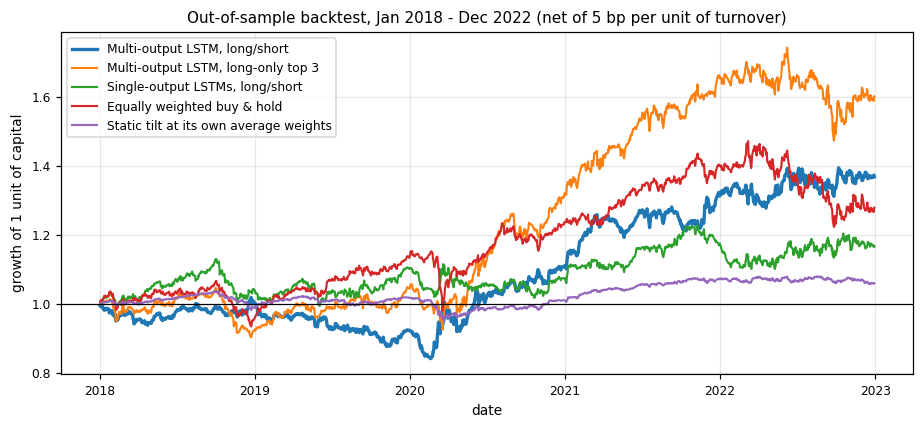

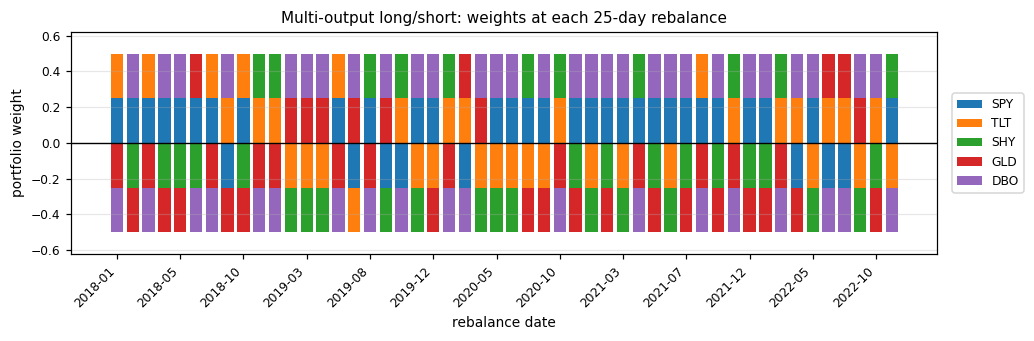

,asset class,average weight,share of periods long %,share of periods short %
SPY,Equity,0.110,60.0,16.0
TLT,Fixed income (long),0.010,38.0,34.0
SHY,Cash-like,-0.075,22.0,52.0
GLD,Precious metals,-0.095,22.0,60.0
DBO,Crude oil,0.050,58.0,38.0


In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 4.0))
for name, v in BT.items():
    ax.plot(test_dates, v["equity"], label=name,
            lw=2.2 if name == "Multi-output LSTM, long/short" else 1.4)
ax.axhline(1.0, color="black", lw=0.8)
ax.set_title(f"Out-of-sample backtest, {test_dates[0]:%b %Y} - {test_dates[-1]:%b %Y}"
             " (net of 5 bp per unit of turnover)")
ax.set_ylabel("growth of 1 unit of capital"); ax.set_xlabel("date")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

v = BT["Multi-output LSTM, long/short"]
W, idx = v["weights"], v["reb_idx"]
fig, ax = plt.subplots(figsize=(9.5, 3.2))
xs = np.arange(len(idx))
base_pos, base_neg = np.zeros(len(idx)), np.zeros(len(idx))
for j, t in enumerate(TICKERS):
    pos, neg = np.clip(W[:, j], 0, None), np.clip(W[:, j], None, 0)
    bars = ax.bar(xs, pos, 0.78, bottom=base_pos, label=t)
    ax.bar(xs, neg, 0.78, bottom=base_neg, color=bars.patches[0].get_facecolor())
    base_pos += pos; base_neg += neg
ax.axhline(0, color="black", lw=0.9); ax.set_ylim(-0.62, 0.62)
step = max(1, len(idx) // 12)
ax.set_xticks(xs[::step], [f"{test_dates[i]:%Y-%m}" for i in idx[::step]],
              rotation=45, ha="right")
ax.set_title("Multi-output long/short: weights at each 25-day rebalance")
ax.set_ylabel("portfolio weight"); ax.set_xlabel("rebalance date")
ax.grid(axis="x", visible=False)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(); plt.show()

# How much of the result is positioning rather than timing?
tilt = pd.DataFrame({
    "asset class": pd.Series(LABELS),
    "average weight": W.mean(axis=0),
    "share of periods long %": (W > 0).mean(axis=0) * 100,
    "share of periods short %": (W < 0).mean(axis=0) * 100,
}, index=TICKERS)
tilt.round(3)